# **Predictive Analytics Using Historical Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("Predictive_Analytics_Historical_Sales_10000.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (10000, 7)


,Date,Customers,Quantity,Average_Price,Promotion,Sales,Profit
0,2018-01-01,187.0,58,407.79,0,181.91,28.93
1,2018-01-02,178.0,117,414.52,1,232.05,38.31
2,2018-01-03,190.0,92,409.29,1,194.57,32.97
3,2018-01-04,204.0,94,422.05,1,193.35,34.75
4,2018-01-05,178.0,85,441.63,0,181.44,24.72


In [3]:
print("Dataset Information:")
print("=" * 50)

df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           10000 non-null  object 
 1   Customers      9975 non-null   float64
 2   Quantity       10000 non-null  int64  
 3   Average_Price  9975 non-null   float64
 4   Promotion      10000 non-null  int64  
 5   Sales          10000 non-null  float64
 6   Profit         10000 non-null  float64
dtypes: float64(4), int64(2), object(1)
memory usage: 547.0+ KB


In [4]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 10000
Number of Columns: 7


In [5]:
df.describe()

,Customers,Quantity,Average_Price,Promotion,Sales,Profit
count,9975.000000,10000.00000,9975.000000,10000.000000,10000.000000,10000.000000
mean,255.197093,176.98290,520.210064,0.213200,406.245708,67.261488
std,47.790408,53.35131,60.661201,0.409588,134.792878,23.916325
min,116.000000,58.00000,373.540000,0.000000,99.280000,15.180000
25%,217.000000,132.00000,470.070000,0.000000,292.540000,47.917500
50%,254.000000,177.00000,520.860000,0.000000,406.385000,66.585000
75%,293.000000,222.00000,571.050000,0.000000,517.772500,85.232500
max,379.000000,300.00000,667.980000,1.000000,722.580000,153.500000


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date              0
Customers        25
Quantity          0
Average_Price    25
Promotion         0
Sales             0
Profit            0
dtype: int64


In [7]:
# Remove rows containing null values
df = df.dropna()

# Check missing values again
print("Missing Values After Removal:")
print(df.isnull().sum())

Missing Values After Removal:
Date             0
Customers        0
Quantity         0
Average_Price    0
Promotion        0
Sales            0
Profit           0
dtype: int64


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date column converted successfully!")
print(df["Date"].dtype)

Date column converted successfully!
datetime64[ns]


In [10]:
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Customers,Quantity,Average_Price,Promotion,Sales,Profit
0,2018-01-01,187.0,58,407.79,0,181.91,28.93
1,2018-01-02,178.0,117,414.52,1,232.05,38.31
2,2018-01-03,190.0,92,409.29,1,194.57,32.97
3,2018-01-04,204.0,94,422.05,1,193.35,34.75
4,2018-01-05,178.0,85,441.63,0,181.44,24.72


In [11]:
df["Customers"] = df["Customers"].fillna(df["Customers"].median())
df["Average_Price"] = df["Average_Price"].fillna(df["Average_Price"].median())

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Date             0
Customers        0
Quantity         0
Average_Price    0
Promotion        0
Sales            0
Profit           0
dtype: int64


In [12]:
print(df.dtypes)

Date             datetime64[ns]
Customers               float64
Quantity                  int64
Average_Price           float64
Promotion                 int64
Sales                   float64
Profit                  float64
dtype: object


In [13]:
df.head(10)

,Date,Customers,Quantity,Average_Price,Promotion,Sales,Profit
0,2018-01-01,187.0,58,407.79,0,181.91,28.93
1,2018-01-02,178.0,117,414.52,1,232.05,38.31
2,2018-01-03,190.0,92,409.29,1,194.57,32.97
3,2018-01-04,204.0,94,422.05,1,193.35,34.75
4,2018-01-05,178.0,85,441.63,0,181.44,24.72
5,2018-01-06,178.0,90,406.22,0,209.73,30.87
6,2018-01-07,206.0,86,438.13,0,155.22,22.04
7,2018-01-08,194.0,95,406.07,1,199.04,35.84
8,2018-01-09,176.0,99,404.90,0,196.53,29.98
9,2018-01-10,191.0,92,434.91,0,184.91,29.92


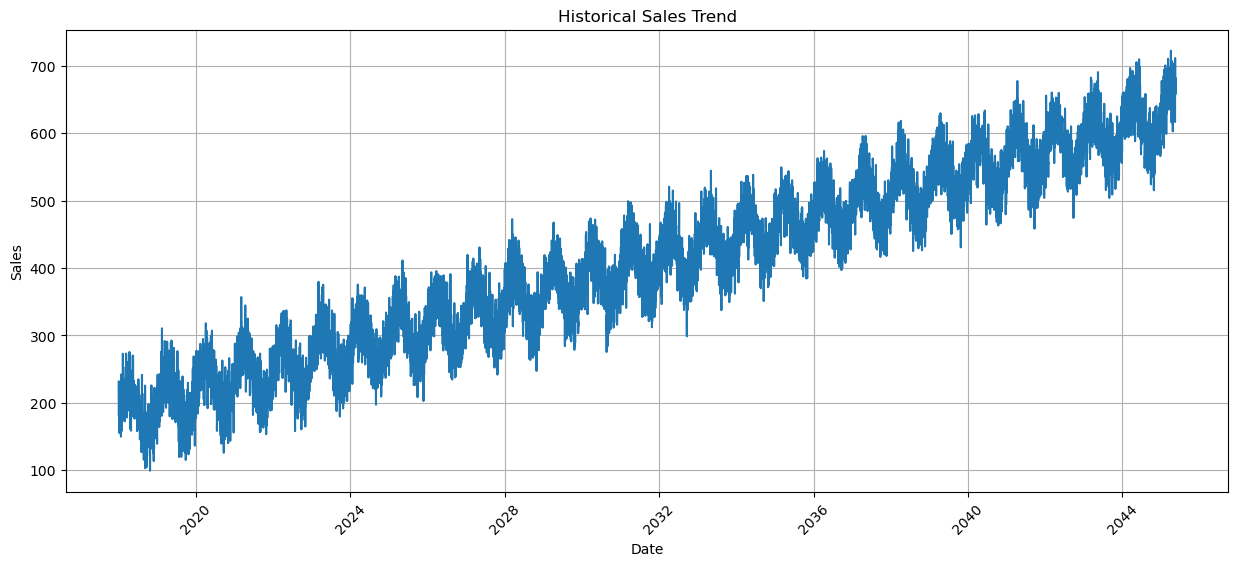

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(df["Date"], df["Sales"])

plt.title("Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

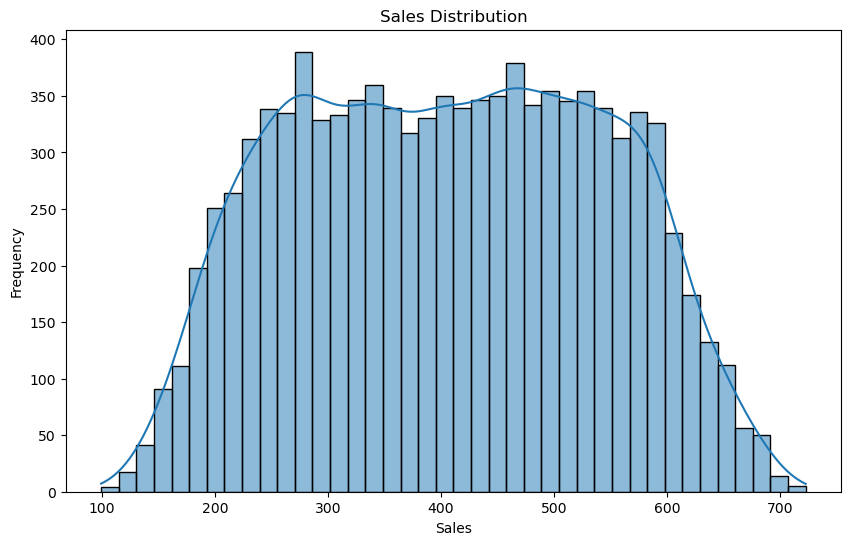

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], bins=40, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [16]:
monthly_sales = df.resample(
    "ME",
    on="Date"
)["Sales"].sum().reset_index()

monthly_sales.head()

,Date,Sales
0,2018-01-31,5826.14
1,2018-02-28,5921.41
2,2018-03-31,6630.57
3,2018-04-30,6523.03
4,2018-05-31,6730.06


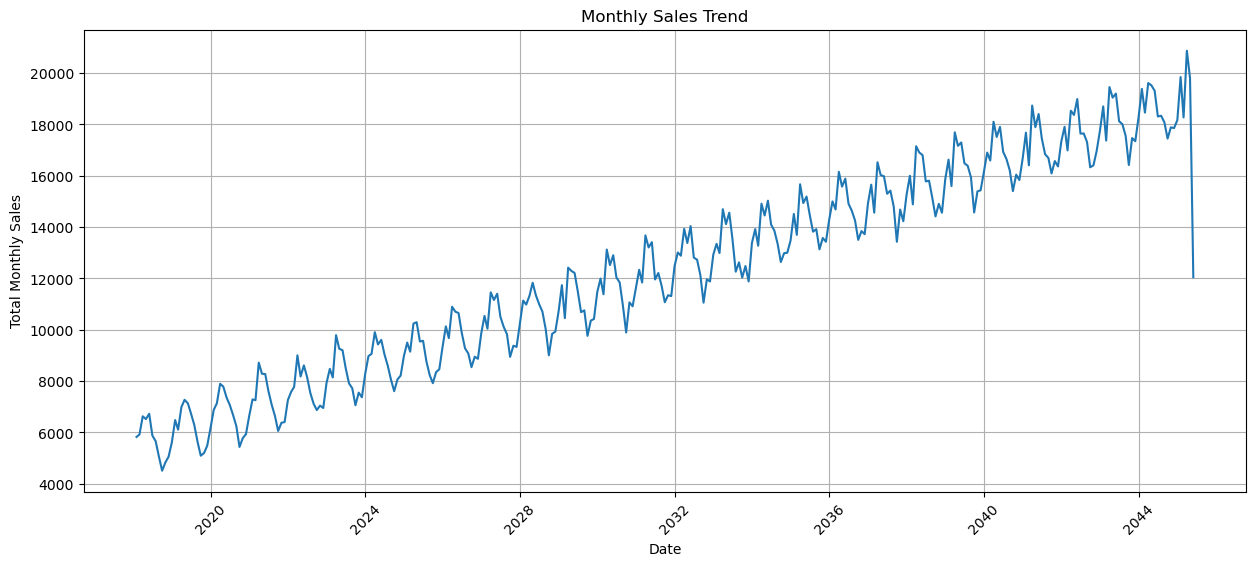

In [17]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Monthly Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [18]:
yearly_sales = df.resample(
    "YE",
    on="Date"
)["Sales"].sum().reset_index()

yearly_sales

,Date,Sales
0,2018-12-31,68248.10
1,2019-12-31,74598.22
2,2020-12-31,80878.34
3,2021-12-31,87277.32
4,2022-12-31,92791.66
5,2023-12-31,99288.44
6,2024-12-31,105567.89
7,2025-12-31,109395.14
8,2026-12-31,116533.10
9,2027-12-31,122972.52


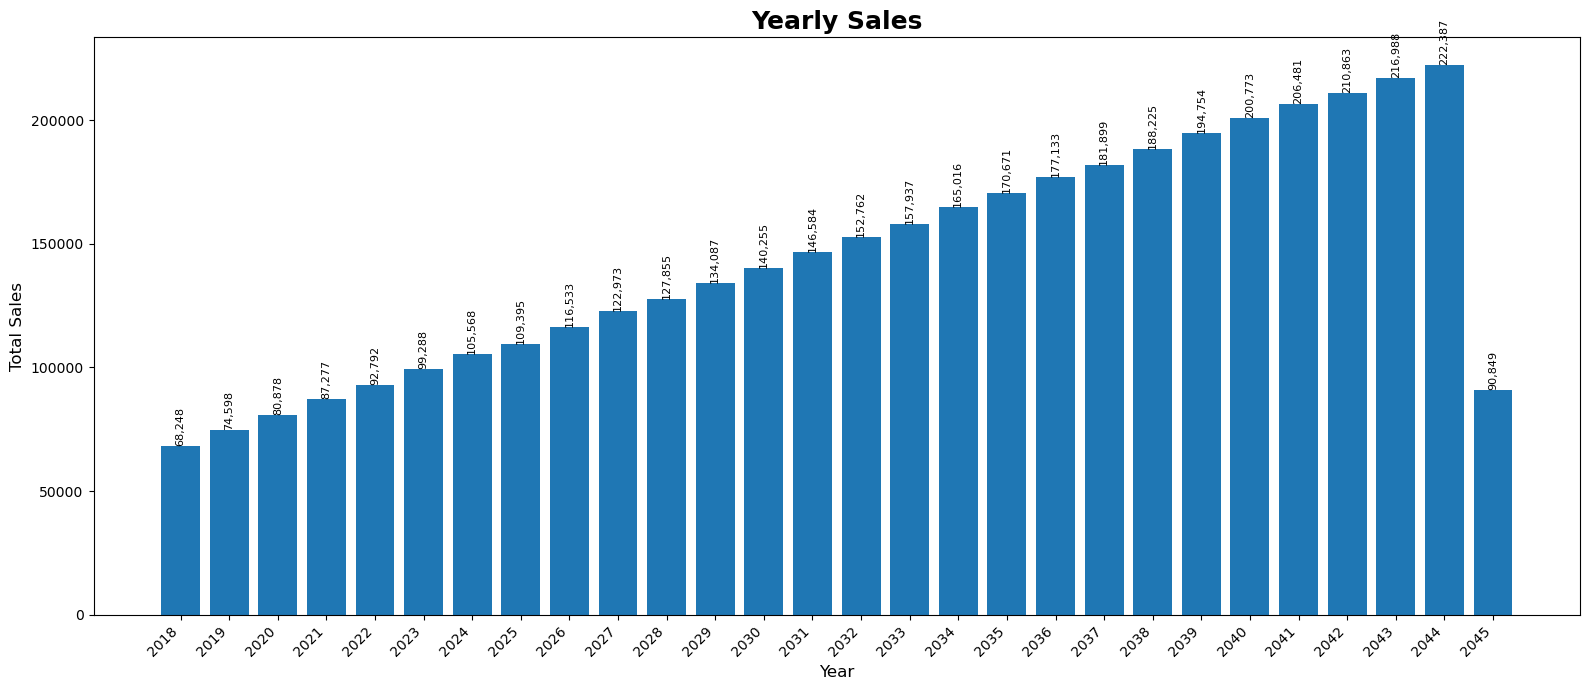

In [19]:
plt.figure(figsize=(16, 7))

bars = plt.bar(
    yearly_sales["Date"].dt.year.astype(str),
    yearly_sales["Sales"]
)

plt.title("Yearly Sales", fontsize=18, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

# Rotate year labels
plt.xticks(rotation=45, ha="right")

# Show sales values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

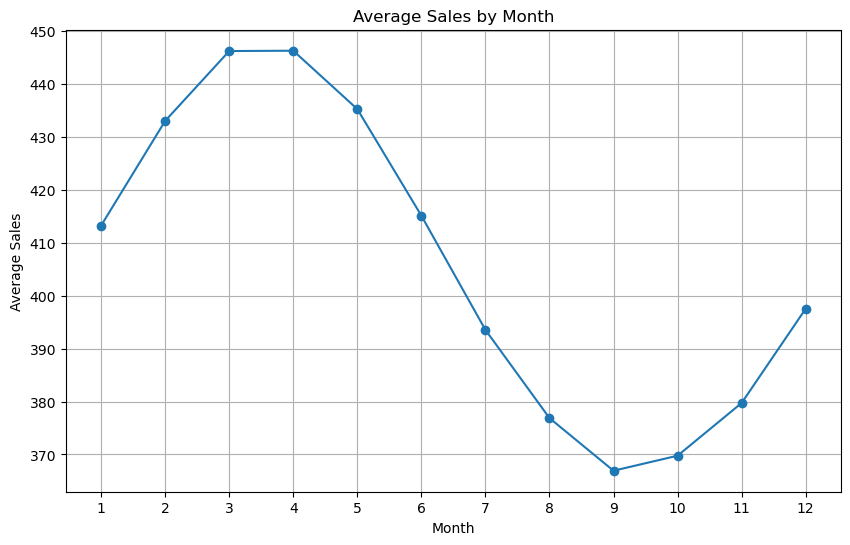

In [20]:
df["Month"] = df["Date"].dt.month

monthly_avg = df.groupby("Month")["Sales"].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

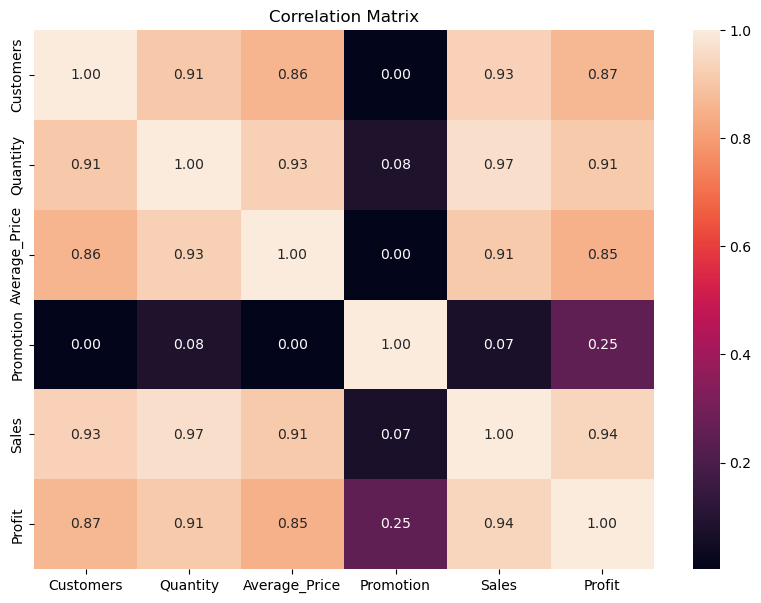

In [21]:
numeric_columns = [
    "Customers",
    "Quantity",
    "Average_Price",
    "Promotion",
    "Sales",
    "Profit"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [22]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["DayOfYear"] = df["Date"].dt.dayofyear

# Continuous time index
df["Time_Index"] = np.arange(len(df))

df.head()

,Date,Customers,Quantity,Average_Price,Promotion,Sales,Profit,Month,Year,Day,DayOfWeek,DayOfYear,Time_Index
0,2018-01-01,187.0,58,407.79,0,181.91,28.93,1,2018,1,0,1,0
1,2018-01-02,178.0,117,414.52,1,232.05,38.31,1,2018,2,1,2,1
2,2018-01-03,190.0,92,409.29,1,194.57,32.97,1,2018,3,2,3,2
3,2018-01-04,204.0,94,422.05,1,193.35,34.75,1,2018,4,3,4,3
4,2018-01-05,178.0,85,441.63,0,181.44,24.72,1,2018,5,4,5,4


In [23]:
df["Sin_Year"] = np.sin(
    2 * np.pi * df["DayOfYear"] / 365.25
)

df["Cos_Year"] = np.cos(
    2 * np.pi * df["DayOfYear"] / 365.25
)

df.head()

,Date,Customers,Quantity,Average_Price,Promotion,Sales,Profit,Month,Year,Day,DayOfWeek,DayOfYear,Time_Index,Sin_Year,Cos_Year
0,2018-01-01,187.0,58,407.79,0,181.91,28.93,1,2018,1,0,1,0,0.017202,0.999852
1,2018-01-02,178.0,117,414.52,1,232.05,38.31,1,2018,2,1,2,1,0.034398,0.999408
2,2018-01-03,190.0,92,409.29,1,194.57,32.97,1,2018,3,2,3,2,0.051584,0.998669
3,2018-01-04,204.0,94,422.05,1,193.35,34.75,1,2018,4,3,4,3,0.068755,0.997634
4,2018-01-05,178.0,85,441.63,0,181.44,24.72,1,2018,5,4,5,4,0.085906,0.996303


In [24]:
features = [
    "Time_Index",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "Sin_Year",
    "Cos_Year"
]

X = df[features]
y = df["Sales"]

print("Features:")
print(features)

print("\nTarget:")
print("Sales")

Features:
['Time_Index', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'Sin_Year', 'Cos_Year']

Target:
Sales


In [25]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 7960
Testing records: 1990


In [26]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [27]:
linear_predictions = linear_model.predict(X_test)

print("First 10 predictions:")

for actual, predicted in zip(
    y_test.head(10),
    linear_predictions[:10]
):
    print(
        f"Actual: {actual:.2f} | "
        f"Predicted: {predicted:.2f}"
    )

First 10 predictions:
Actual: 511.22 | Predicted: 500.45
Actual: 530.03 | Predicted: 512.39
Actual: 537.37 | Predicted: 510.08
Actual: 524.87 | Predicted: 507.78
Actual: 524.83 | Predicted: 532.61
Actual: 500.33 | Predicted: 530.31
Actual: 553.34 | Predicted: 528.03
Actual: 543.71 | Predicted: 525.75
Actual: 531.59 | Predicted: 537.74
Actual: 571.70 | Predicted: 535.47


In [28]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print("=" * 40)

print("MAE :", round(linear_mae, 2))
print("MSE :", round(linear_mse, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression Performance
MAE : 19.04
MSE : 567.26
RMSE: 23.82
R²  : 0.7326


In [29]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# Make predictions on test data
rf_predictions = rf_model.predict(X_test)

print("Predictions created successfully!")

Predictions created successfully!


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

# Display results
print("Random Forest Performance")
print("=" * 40)
print("MAE  :", round(rf_mae, 2))
print("MSE  :", round(rf_mse, 2))
print("RMSE :", round(rf_rmse, 2))
print("R²   :", round(rf_r2, 4))

Random Forest Performance
MAE  : 51.82
MSE  : 3711.54
RMSE : 60.92
R²   : -0.7492


In [32]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,19.037852,23.817322,0.732648
1,Random Forest,51.818276,60.922385,-0.749249


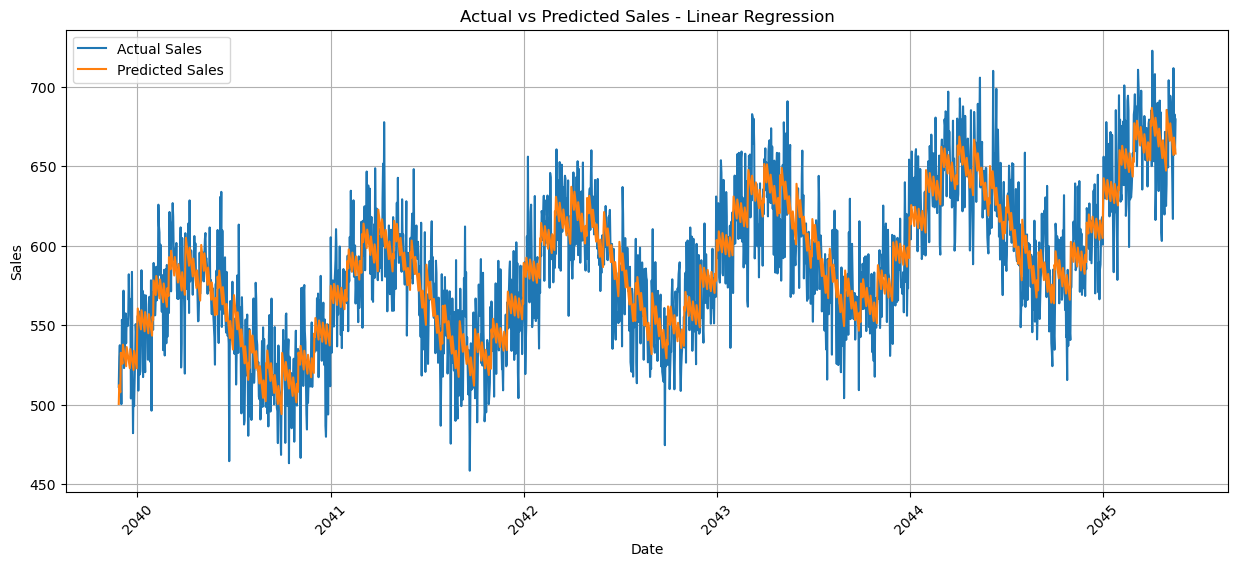

In [33]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"].iloc[split_index:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    df["Date"].iloc[split_index:],
    linear_predictions,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales - Linear Regression")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [34]:
last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=90,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates
})

future_df.head()

,Date
0,2045-05-19
1,2045-05-20
2,2045-05-21
3,2045-05-22
4,2045-05-23


In [35]:
future_df["Year"] = future_df["Date"].dt.year
future_df["Month"] = future_df["Date"].dt.month
future_df["Day"] = future_df["Date"].dt.day
future_df["DayOfWeek"] = future_df["Date"].dt.dayofweek
future_df["DayOfYear"] = future_df["Date"].dt.dayofyear

future_df["Time_Index"] = np.arange(
    len(df),
    len(df) + len(future_df)
)

future_df["Sin_Year"] = np.sin(
    2 * np.pi * future_df["DayOfYear"] / 365.25
)

future_df["Cos_Year"] = np.cos(
    2 * np.pi * future_df["DayOfYear"] / 365.25
)

future_X = future_df[features]

future_df.head()

,Date,Year,Month,Day,DayOfWeek,DayOfYear,Time_Index,Sin_Year,Cos_Year
0,2045-05-19,2045,5,19,4,139,9950,0.681972,-0.731378
1,2045-05-20,2045,5,20,5,140,9951,0.669290,-0.743001
2,2045-05-21,2045,5,21,6,141,9952,0.656411,-0.754404
3,2045-05-22,2045,5,22,0,142,9953,0.643337,-0.765584
4,2045-05-23,2045,5,23,1,143,9954,0.630072,-0.776537


In [36]:
future_predictions = linear_model.predict(
    future_X
)

future_df["Predicted_Sales"] = future_predictions

future_df.head(10)

,Date,Year,Month,Day,DayOfWeek,DayOfYear,Time_Index,Sin_Year,Cos_Year,Predicted_Sales
0,2045-05-19,2045,5,19,4,139,9950,0.681972,-0.731378,654.509759
1,2045-05-20,2045,5,20,5,140,9951,0.669290,-0.743001,651.123362
2,2045-05-21,2045,5,21,6,141,9952,0.656411,-0.754404,647.728693
3,2045-05-22,2045,5,22,0,142,9953,0.643337,-0.765584,658.588613
4,2045-05-23,2045,5,23,1,143,9954,0.630072,-0.776537,655.177853
5,2045-05-24,2045,5,24,2,144,9955,0.616621,-0.787260,651.759278
6,2045-05-25,2045,5,25,3,145,9956,0.602988,-0.797750,648.333045
7,2045-05-26,2045,5,26,4,146,9957,0.589176,-0.808005,644.899315
8,2045-05-27,2045,5,27,5,147,9958,0.575190,-0.818020,641.458248
9,2045-05-28,2045,5,28,6,148,9959,0.561034,-0.827793,638.010008


In [37]:
future_forecast = future_df[
    ["Date", "Predicted_Sales"]
].copy()

future_forecast["Predicted_Sales"] = (
    future_forecast["Predicted_Sales"].round(2)
)

future_forecast

,Date,Predicted_Sales
0,2045-05-19,654.51
1,2045-05-20,651.12
2,2045-05-21,647.73
3,2045-05-22,658.59
4,2045-05-23,655.18
...,...,...
85,2045-08-12,607.97
86,2045-08-13,604.54
87,2045-08-14,615.39
88,2045-08-15,611.98


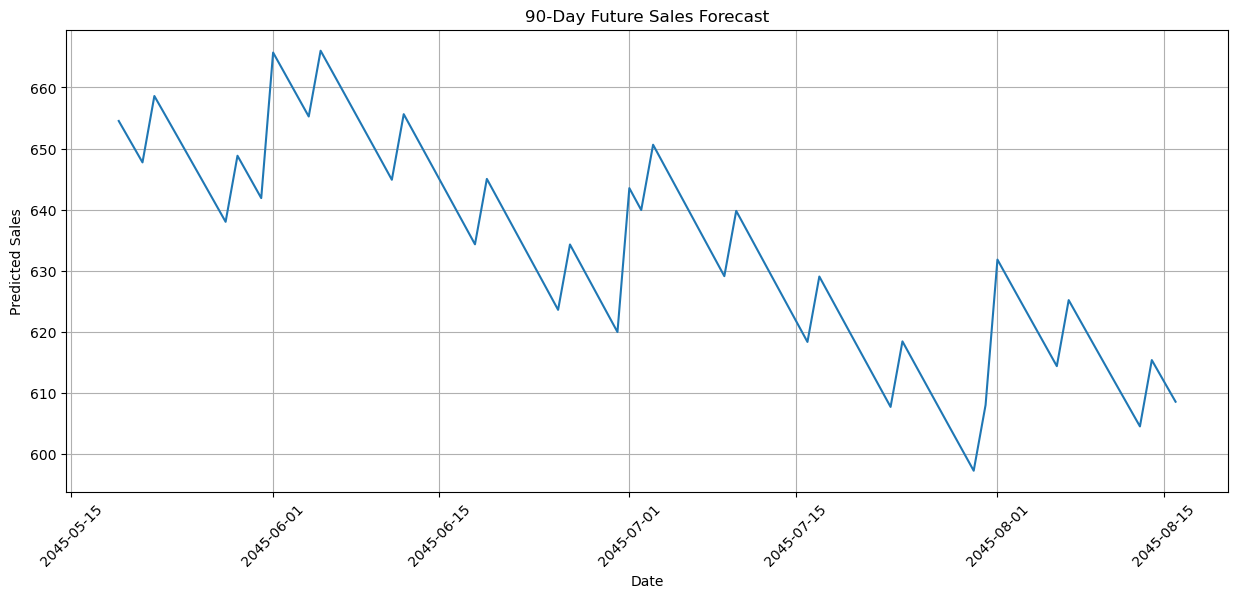

In [38]:
plt.figure(figsize=(15, 6))

plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Sales"]
)

plt.title("90-Day Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

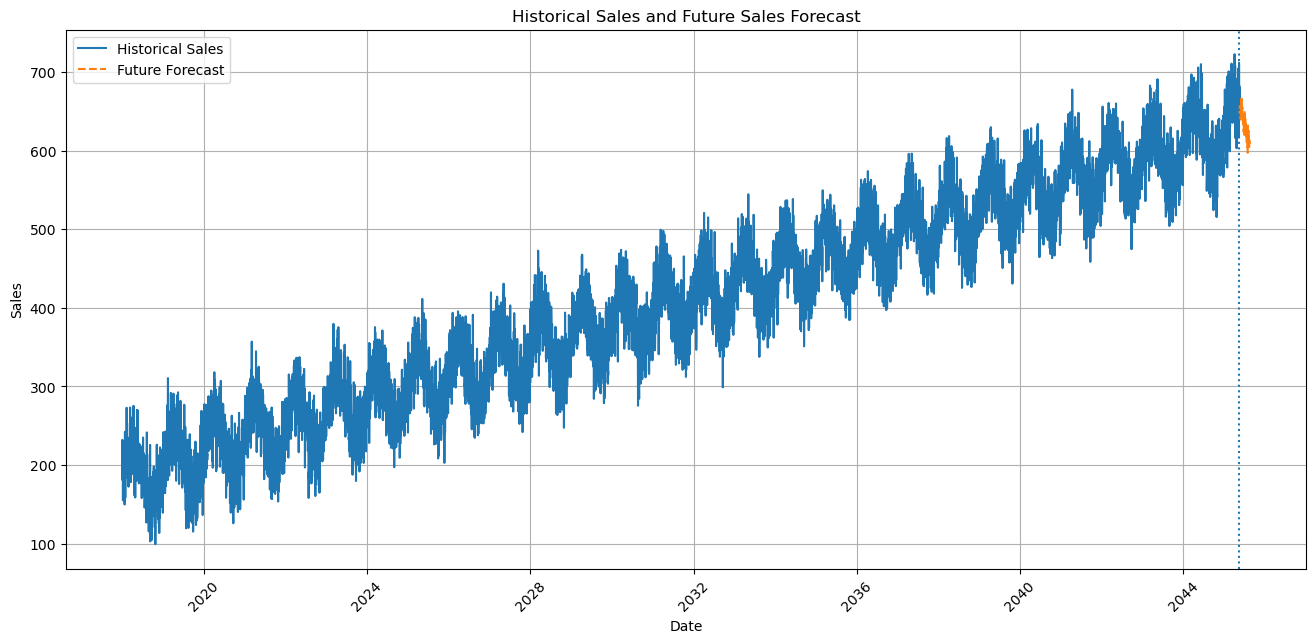

In [39]:
plt.figure(figsize=(16, 7))

# Historical sales
plt.plot(
    df["Date"],
    df["Sales"],
    label="Historical Sales"
)

# Future predictions
plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Sales"],
    linestyle="--",
    label="Future Forecast"
)

plt.axvline(
    df["Date"].max(),
    linestyle=":"
)

plt.title(
    "Historical Sales and Future Sales Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [40]:
test_predictions = pd.DataFrame({
    "Date": df["Date"].iloc[split_index:].values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": linear_predictions
})

test_predictions["Error"] = (
    test_predictions["Actual_Sales"]
    - test_predictions["Predicted_Sales"]
)

test_predictions.to_csv(
    "test_predictions.csv",
    index=False
)

print("Test predictions saved successfully!")

Test predictions saved successfully!


In [41]:
future_forecast.to_csv(
    "future_sales_forecast.csv",
    index=False
)

print("Future forecast saved successfully!")

Future forecast saved successfully!


In [42]:
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print(f"MAE  : {linear_mae:.2f}")
print(f"MSE  : {linear_mse:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")

FINAL MODEL PERFORMANCE
MAE  : 19.04
MSE  : 567.26
RMSE : 23.82
R²   : 0.7326


In [43]:
if rf_rmse < linear_rmse:
    best_model = "Random Forest"
    best_rmse = rf_rmse
    best_r2 = rf_r2
else:
    best_model = "Linear Regression"
    best_rmse = linear_rmse
    best_r2 = linear_r2

print("Best Model:", best_model)
print("RMSE:", round(best_rmse, 2))
print("R² Score:", round(best_r2, 4))

Best Model: Linear Regression
RMSE: 23.82
R² Score: 0.7326


In [44]:
print("KEY INSIGHTS")
print("=" * 50)

print("1. Historical sales show an overall time-based trend.")

print("2. Sales vary across different months, indicating seasonality.")

print("3. The dataset contains customer, quantity, price and promotion information.")

print("4. Two machine learning models were evaluated:")
print("   - Linear Regression")
print("   - Random Forest Regression")

print("5. Model performance was evaluated using MAE, MSE, RMSE and R².")

print("6. Future sales were forecasted for the next 90 days.")

print("7. The forecast can help businesses plan inventory, staffing and sales strategies.")

KEY INSIGHTS
1. Historical sales show an overall time-based trend.
2. Sales vary across different months, indicating seasonality.
3. The dataset contains customer, quantity, price and promotion information.
4. Two machine learning models were evaluated:
   - Linear Regression
   - Random Forest Regression
5. Model performance was evaluated using MAE, MSE, RMSE and R².
6. Future sales were forecasted for the next 90 days.
7. The forecast can help businesses plan inventory, staffing and sales strategies.


In [45]:
import pickle

with open("sales_prediction_model.pkl", "wb") as file:
    pickle.dump(linear_model, file)

print("Pickle file created successfully!")

Pickle file created successfully!


In [46]:
with open("sales_prediction_model.pkl", "rb") as file:
    model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!
